# Experiment results

Reuses the exact same aggregation/plotting code from `experiments/results.py` (`build_summary_rows`,
`plot_efficiency_frontier`, `plot_latency_distribution`, `plot_per_field_accuracy`).

In [1]:
import sys
from pathlib import Path

# Jupyter's cwd is usually the notebook's own directory (experiments/), not the repo
# root, so `import experiments...` fails unless the repo root is on sys.path.
for _candidate in (Path.cwd(), Path.cwd().parent):
    if (_candidate / "experiments" / "results.py").exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

import pandas as pd
from IPython.display import Image, display

from experiments.config import DEFAULT_EXPERIMENT, GROUND_TRUTH_KEY, MODEL_REGISTRY
from experiments.results import (
    DEFAULT_EVALUATIONS_ROOT,
    DEFAULT_OUTPUT_DIR,
    DEFAULT_RUNS_ROOT,
    _discover_latest_runs,
    _raw_wall_seconds,
    build_summary_rows,
    plot_efficiency_frontier,
    plot_latency_distribution,
    plot_per_field_accuracy,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

## Select runs

Defaults to the most recent run per `model_key` under `experiments/runs`, matching
the CLI's default. To pin specific runs instead (mirrors `--run` on the CLI), set
`selected_runs` explicitly, e.g.:

```python
from experiments.results import _resolve_explicit_runs
selected_runs = _resolve_explicit_runs(["gpt-oss-120b__20260715T101500Z", ...], DEFAULT_RUNS_ROOT)
```

In [2]:
selected_runs = _discover_latest_runs(DEFAULT_RUNS_ROOT)
if not selected_runs:
    raise SystemExit(
        f"No runs found under {DEFAULT_RUNS_ROOT} -- run experiments/runner.py first."
    )

for model_key, run_dir in selected_runs.items():
    print(f"{model_key:>16}  ->  {run_dir}")

    gliner2-base  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/baseline__gliner2-base__20260720T180845Z
    gpt-oss-120b  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/baseline__gpt-oss-120b__20260720T180845Z
      qwen3-0.6b  ->  /projectnb/mcnet/kevin/infoextraction/govscape-extract/experiments/runs/baseline__qwen3-0.6b__20260720T180845Z


## Summary table

In [3]:
rows = build_summary_rows(selected_runs, DEFAULT_EVALUATIONS_ROOT)
df = pd.DataFrame(rows)
display(df)

,model_key,role,n_documents,wall_seconds_total,wall_seconds_mean,wall_seconds_stdev,overall_similarity_mean,overall_similarity_stdev,title_similarity,authors_similarity,publication_date_similarity,government_agency_similarity,document_type_similarity
0,gliner2-base,candidate,100,727.220099,7.272201,10.117689,0.516753,0.221796,0.378062,0.756667,0.65500,0.454036,0.34
1,gpt-oss-120b,ground_truth,100,98.359063,0.983591,0.272870,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,qwen3-0.6b,candidate,100,23.960438,0.239604,0.142263,0.520989,0.194212,0.707881,0.466667,0.56209,0.538308,0.33


## Plots


In [6]:
plots_dir = DEFAULT_OUTPUT_DIR / "plots"
plots_dir.mkdir(parents=True, exist_ok=True)

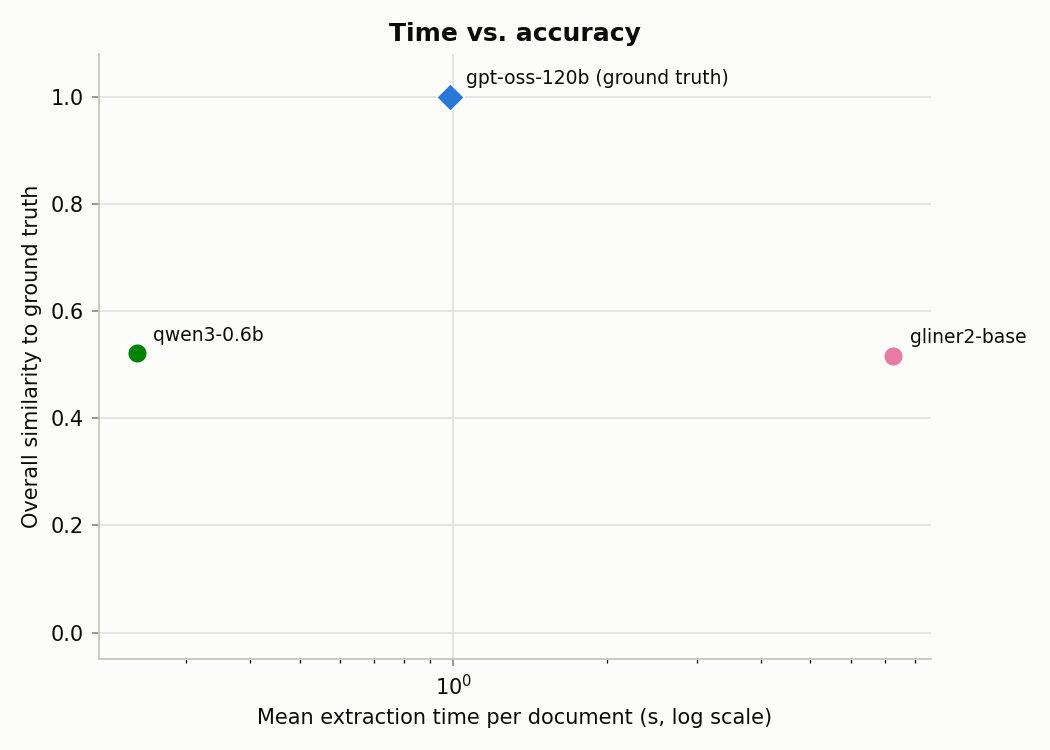

In [7]:
# Time vs. accuracy
path = plots_dir / "efficiency_frontier.png"
plot_efficiency_frontier(rows, path)
display(Image(filename=str(path)))

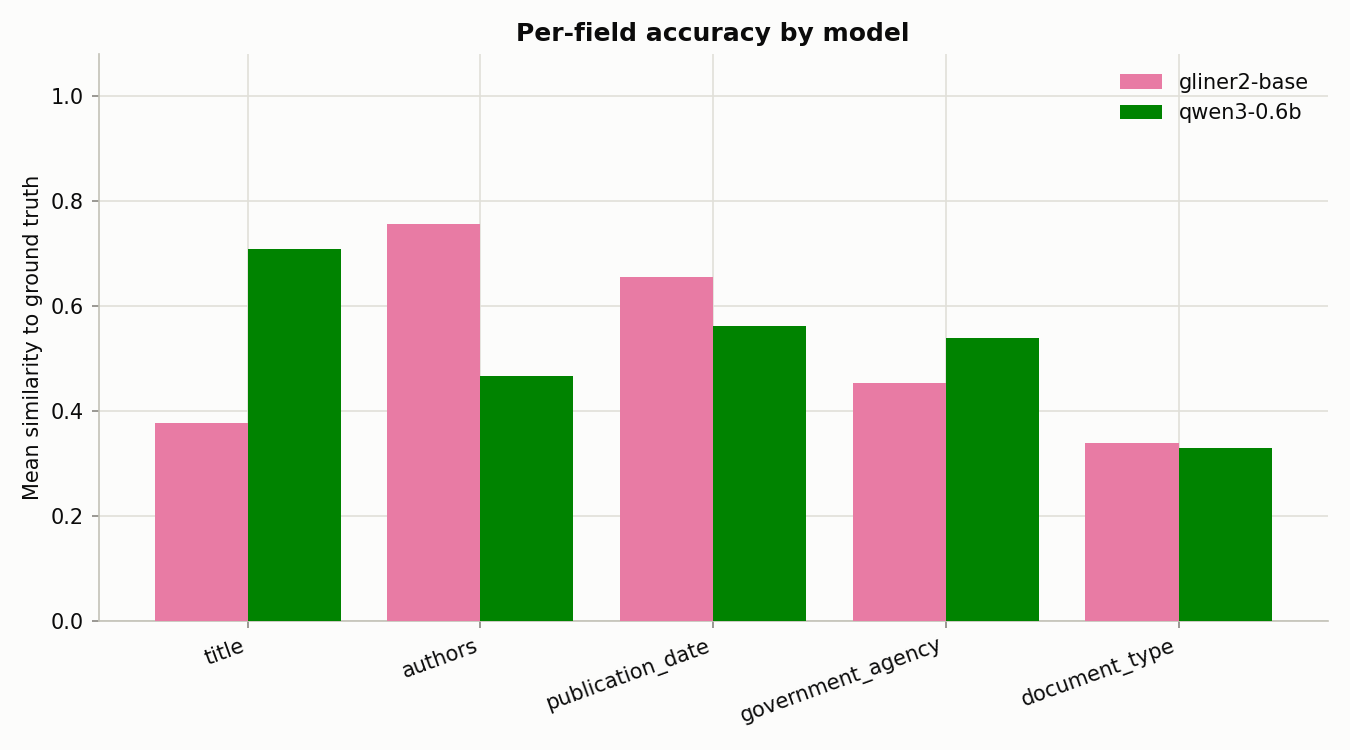

In [9]:
# Per-field accuracy
path = plots_dir / "per_field_accuracy.png"
plot_per_field_accuracy(rows, path)
display(Image(filename=str(path)))